In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("./files/prj_data.csv")
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,재구매 유도 대상,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,재구매 유도 대상,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,NaN,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,재구매 유도 대상,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,NaN,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       460 non-null    float64
 2   성별       485 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     480 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     475 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  메모       216 non-null    str    
 11  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 47.0 KB


In [3]:
df.shape

(500, 12)

In [4]:
# 비교용 전처리 작업 전 데이터프레임을 df_origin에 저장

df_origin = df.copy()

In [5]:
df.isnull().sum()

고객ID         0
나이          40
성별          15
거주지역         0
가입경로        20
멤버십등급        0
월평균구매금액      0
구매횟수         0
리뷰점수        25
쿠폰사용여부       0
메모         284
이탈여부         0
dtype: int64

In [6]:
missing_ratio = df.isnull().mean()
missing_ratio

고객ID       0.000
나이         0.080
성별         0.030
거주지역       0.000
가입경로       0.040
멤버십등급      0.000
월평균구매금액    0.000
구매횟수       0.000
리뷰점수       0.050
쿠폰사용여부     0.000
메모         0.568
이탈여부       0.000
dtype: float64

In [7]:
missing_ratio[missing_ratio > 0.5]

메모    0.568
dtype: float64

In [8]:
drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()

drop_cols

['메모']

In [9]:
df = df.drop(columns=drop_cols)

In [10]:
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0


In [11]:
num_cols_na = df.select_dtypes(include="number").columns 
num_cols_na

Index(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부'], dtype='str')

In [12]:
num_cols_na = num_cols_na[df[num_cols_na].isnull().any()]
num_cols_na

Index(['나이', '리뷰점수'], dtype='str')

In [13]:
df[num_cols_na].agg(["mean", "median"])

,나이,리뷰점수
mean,43.195652,3.736632
median,43.000000,3.700000


In [14]:
# "나이", "리뷰점수" 두 컬럼 모두 평균과 중앙값이 거의 비슷한 값이지만
# 평균은 반올림이 필요하기 때문에 두 컬럼의 결측치는 중앙값으로 대체한다.

for c in num_cols_na:
    df[c] = df[c].fillna(df[c].median())

df[num_cols_na].isnull().sum()

나이      0
리뷰점수    0
dtype: int64

In [15]:
cat_cols_na = df.select_dtypes(exclude="number").columns
cat_cols_na

Index(['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부'], dtype='str')

In [16]:

cat_cols_na = cat_cols_na[df[cat_cols_na].isnull().any()]
cat_cols_na

Index(['성별', '가입경로'], dtype='str')

In [17]:
df["성별"].value_counts()

성별
여    255
남    230
Name: count, dtype: int64

In [18]:
df["가입경로"].value_counts()

가입경로
앱       188
웹       150
광고       80
지인추천     62
Name: count, dtype: int64

In [19]:
# "성별", "가입경로" 두 컬럼의 결측치를 최빈값으로 채운다.

df["성별"] = df["성별"].fillna(df["성별"].mode()[0])
df["가입경로"] = df["가입경로"].fillna(df["가입경로"].mode()[0])

In [20]:
df[cat_cols_na].isnull().sum()

성별      0
가입경로    0
dtype: int64

In [21]:
df.isnull().sum()

고객ID       0
나이         0
성별         0
거주지역       0
가입경로       0
멤버십등급      0
월평균구매금액    0
구매횟수       0
리뷰점수       0
쿠폰사용여부     0
이탈여부       0
dtype: int64

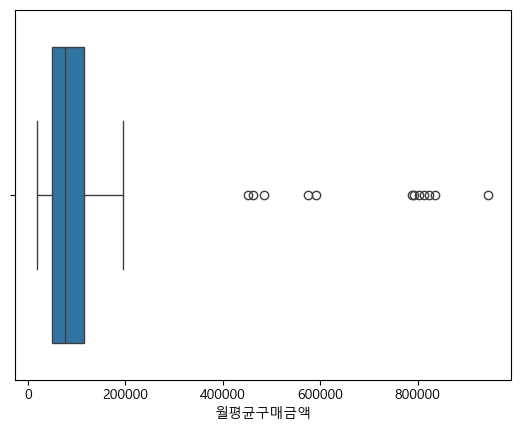

In [22]:
sns.boxplot(x=df["월평균구매금액"])
plt.show()

In [23]:
q1 = df["월평균구매금액"].quantile(.25)

q3 = df["월평균구매금액"].quantile(.75)

q1, q3

(np.float64(48362.456334193215), np.float64(114551.09835296536))

In [24]:
iqr = q3 - q1
iqr

np.float64(66188.64201877214)

In [25]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

lower, upper

(np.float64(-50920.50669396499), np.float64(213834.06138112355))

In [26]:
lower = max(lower, 0)
lower

0

In [27]:
n_outlier = ((df["월평균구매금액"] < lower) | (df["월평균구매금액"] > upper)).sum()
n_outlier

np.int64(12)

In [28]:
# 이 데이터는 구매고객과 관련된 데이터로 보이므로
# "월평균구매금액"이 0 이하라면 구매고객이 아닌 오류로 입력된 값이라고 추정할 수 있다. 따라서 삭제한다.
# "월평균구매금액"이 상한을 초과하는 값들은 일부 고객의 극단값이므로 상한으로 맞추어 완하한다.

df = df[df["월평균구매금액"] > lower]

df["월평균구매금액"] = df["월평균구매금액"].clip(upper=upper)

df["월평균구매금액"]

0       62705.653045
1      180896.754122
2       30567.640969
3       71563.606370
4      107967.380320
           ...      
495    108578.954159
496     40162.047877
497     51493.570059
498    105068.989111
499     70073.592144
Name: 월평균구매금액, Length: 500, dtype: float64

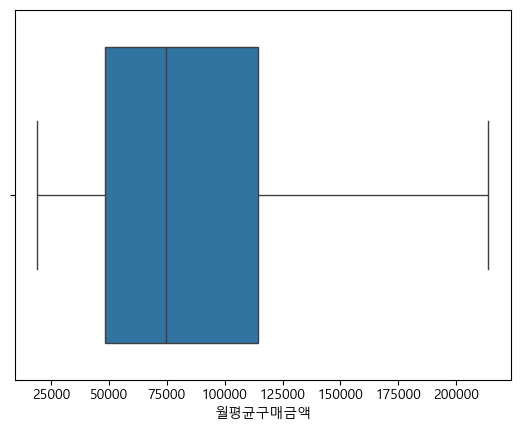

In [29]:
sns.boxplot(x=df["월평균구매금액"])
plt.show()

In [30]:
# 인코딩 전 데이터프레임 형태(shape)

df.shape

(500, 11)

In [31]:
# 비교용 인코딩 전 데이터프레임을 df_null_after에 저장

df_null_after = df.copy()

In [32]:
df.select_dtypes(exclude="number").columns

Index(['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부'], dtype='str')

In [33]:
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0


In [34]:
df["멤버십등급"].value_counts()

멤버십등급
브론즈    192
실버     142
골드     111
VIP     55
Name: count, dtype: int64

In [35]:
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0


In [36]:
# 멤버십등급은 등급의 순서의 의미가 있다고 볼 수 있다.
# 따라서, 원-핫 인코딩보다 레이블 인코딩이 적합하다.
# (브론즈: 0, 실버: 1, 골드: 2, VIP: 3) 으로 인코딩한다.

membership = LabelEncoder()
membership.fit(df["멤버십등급"])
membership.classes_ = np.array(["브론즈", "실버", "골드", "VIP"])

df["멤버십등급"] = membership.transform(df["멤버십등급"])
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,1,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,3,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,0,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,1,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,2,107967.380320,7.0,4.9,N,0


In [37]:
# 멤버십등급을 제외한 나머지 범주형 컬럼들은 순서에 의미가 있다고 보기 어렵다.
# 따라서 원-핫 인코딩이 더 적합하다.

df = pd.get_dummies(data=df, columns=["성별", "거주지역", "가입경로", "쿠폰사용여부"])
df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y
0,C0001,22.0,1,62705.653045,7.0,3.3,1,True,False,False,False,True,False,False,False,True,False,False,True,False
1,C0002,58.0,3,180896.754122,18.0,4.7,0,False,True,False,False,False,True,False,False,False,True,False,False,True
2,C0003,52.0,0,30567.640969,3.0,3.3,0,False,True,False,True,False,False,False,False,True,False,False,False,True
3,C0004,40.0,1,71563.606370,3.0,3.8,0,False,True,True,False,False,False,False,False,True,False,False,True,False
4,C0005,40.0,2,107967.380320,7.0,4.9,0,True,False,True,False,False,False,False,False,False,True,False,True,False


In [38]:
# 인코딩 전, 후 데이터프레임 형태(shape) 비교

print(f"원본 데이터프레임 형태 : {df_origin.shape[0]}행, {df_origin.shape[1]}열\n")
print(f"결측치 처리 후 인코딩 전 데이터프레임 형태 : {df_null_after.shape[0]}행, {df_null_after.shape[1]}열\n")
print(f"인코딩 후 데이터프레임 형태 : {df.shape[0]}행, {df.shape[1]}열\n")
print(f"{df_origin.shape}, {df_null_after.shape}, {df.shape}")

원본 데이터프레임 형태 : 500행, 12열

결측치 처리 후 인코딩 전 데이터프레임 형태 : 500행, 11열

인코딩 후 데이터프레임 형태 : 500행, 20열

(500, 12), (500, 11), (500, 20)


In [39]:
# 비교용 인코딩 후 데이터프레임을 df_encoding_after에 저장

df_encoding_after = df.copy()

In [40]:
# 평균구매단가 컬럼을 만들기 전, 분모가 0이 되는 샘플이 있는지 확인

(df["구매횟수"] == 0).sum()

np.int64(0)

In [41]:
df["평균구매단가"] = df["월평균구매금액"] / df["구매횟수"]

df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,...,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,평균구매단가
0,C0001,22.0,1,62705.653045,7.0,3.3,1,True,False,False,...,True,False,False,False,True,False,False,True,False,8957.950435
1,C0002,58.0,3,180896.754122,18.0,4.7,0,False,True,False,...,False,True,False,False,False,True,False,False,True,10049.819673
2,C0003,52.0,0,30567.640969,3.0,3.3,0,False,True,False,...,False,False,False,False,True,False,False,False,True,10189.213656
3,C0004,40.0,1,71563.606370,3.0,3.8,0,False,True,True,...,False,False,False,False,True,False,False,True,False,23854.535457
4,C0005,40.0,2,107967.380320,7.0,4.9,0,True,False,True,...,False,False,False,False,False,True,False,True,False,15423.911474


In [42]:
scale_cols = ["나이", "월평균구매금액", "구매횟수", "리뷰점수",  "평균구매단가"]
df[scale_cols]

,나이,월평균구매금액,구매횟수,리뷰점수,평균구매단가
0,22.0,62705.653045,7.0,3.3,8957.950435
1,58.0,180896.754122,18.0,4.7,10049.819673
2,52.0,30567.640969,3.0,3.3,10189.213656
3,40.0,71563.606370,3.0,3.8,23854.535457
4,40.0,107967.380320,7.0,4.9,15423.911474
...,...,...,...,...,...
495,39.0,108578.954159,9.0,3.5,12064.328240
496,24.0,40162.047877,6.0,3.6,6693.674646
497,37.0,51493.570059,3.0,4.1,17164.523353
498,66.0,105068.989111,6.0,4.4,17511.498185


In [43]:
df[scale_cols].describe().loc[["mean", "std"]]

,나이,월평균구매금액,구매횟수,리뷰점수,평균구매단가
mean,43.180000,86092.413399,7.822000,3.734800,13129.800389
std,14.384764,47003.366902,4.481795,0.540382,8858.181124


In [44]:
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,...,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,평균구매단가
0,C0001,-1.473866,1,-0.498053,-0.183592,-0.805421,1,True,False,False,...,True,False,False,False,True,False,False,True,False,-0.471432
1,C0002,1.031289,3,2.018989,2.273239,1.787932,0,False,True,False,...,False,True,False,False,False,True,False,False,True,-0.348047
2,C0003,0.613763,0,-1.182477,-1.076986,-0.805421,0,False,True,False,...,False,False,False,False,True,False,False,False,True,-0.332295
3,C0004,-0.221289,1,-0.309411,-1.076986,0.120776,0,False,True,True,...,False,False,False,False,True,False,False,True,False,1.211928
4,C0005,-0.221289,2,0.465858,-0.183592,2.158411,0,True,False,True,...,False,False,False,False,False,True,False,True,False,0.259242


In [45]:
print("원본 데이터 프레임")
display(df_origin.describe())

print("\n결측치 처리 후 인코딩 전 데이터프레임")
display(df_null_after.describe())

print("\n인코딩 후 스케일링 전 데이터프레임")
display(df_encoding_after.describe())

print("\n스케일링 후 데이터프레임")
display(df.describe())

원본 데이터 프레임


,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,460.000000,500.000000,500.000000,475.000000,500.000000
mean,43.195652,97684.003413,7.822000,3.736632,0.380000
std,14.998358,106309.940848,4.481795,0.554389,0.485873
min,18.000000,19127.903927,1.000000,2.500000,0.000000
25%,30.000000,48362.456334,4.000000,3.400000,0.000000
50%,43.000000,74770.324856,7.000000,3.700000,0.000000
75%,56.250000,114551.098353,10.250000,4.100000,1.000000
max,69.000000,945072.807028,21.000000,5.000000,1.000000



결측치 처리 후 인코딩 전 데이터프레임


,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,86092.413399,7.822000,3.734800,0.380000
std,14.384764,47003.366902,4.481795,0.540382,0.485873
min,18.000000,19127.903927,1.000000,2.500000,0.000000
25%,32.000000,48362.456334,4.000000,3.400000,0.000000
50%,43.000000,74770.324856,7.000000,3.700000,0.000000
75%,56.000000,114551.098353,10.250000,4.100000,1.000000
max,69.000000,213834.061381,21.000000,5.000000,1.000000



인코딩 후 스케일링 전 데이터프레임


,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,1.058000,86092.413399,7.822000,3.734800,0.380000
std,14.384764,1.022118,47003.366902,4.481795,0.540382,0.485873
min,18.000000,0.000000,19127.903927,1.000000,2.500000,0.000000
25%,32.000000,0.000000,48362.456334,4.000000,3.400000,0.000000
50%,43.000000,1.000000,74770.324856,7.000000,3.700000,0.000000
75%,56.000000,2.000000,114551.098353,10.250000,4.100000,1.000000
max,69.000000,3.000000,213834.061381,21.000000,5.000000,1.000000



스케일링 후 데이터프레임


,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,평균구매단가
count,5.000000e+02,500.000000,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,5.000000e+02
mean,1.776357e-18,1.058000,7.815970e-17,-2.842171e-17,-6.359357e-16,0.380000,1.127987e-16
std,1.001002e+00,1.022118,1.001002e+00,1.001002e+00,1.001002e+00,0.485873,1.001002e+00
min,-1.752216e+00,0.000000,-1.426102e+00,-1.523682e+00,-2.287338e+00,0.000000,-1.174920e+00
25%,-7.779896e-01,0.000000,-8.035115e-01,-8.536373e-01,-6.201819e-01,0.000000,-4.901749e-01
50%,-1.252577e-02,1.000000,-2.411195e-01,-1.835923e-01,-6.446335e-02,0.000000,-2.571468e-01
75%,8.921133e-01,2.000000,6.060669e-01,5.422898e-01,6.764947e-01,1.000000,8.219864e-02
max,1.796752e+00,3.000000,2.720435e+00,2.943284e+00,2.343650e+00,1.000000,6.570926e+00


In [46]:
df.to_csv("./files/prj_data_cleaned.csv", index=False, encoding="utf-8-sig")

In [47]:
pd.read_csv("./files/prj_data_cleaned.csv")

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,...,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,평균구매단가
0,C0001,-1.473866,1,-0.498053,-0.183592,-0.805421,1,True,False,False,...,True,False,False,False,True,False,False,True,False,-0.471432
1,C0002,1.031289,3,2.018989,2.273239,1.787932,0,False,True,False,...,False,True,False,False,False,True,False,False,True,-0.348047
2,C0003,0.613763,0,-1.182477,-1.076986,-0.805421,0,False,True,False,...,False,False,False,False,True,False,False,False,True,-0.332295
3,C0004,-0.221289,1,-0.309411,-1.076986,0.120776,0,False,True,True,...,False,False,False,False,True,False,False,True,False,1.211928
4,C0005,-0.221289,2,0.465858,-0.183592,2.158411,0,True,False,True,...,False,False,False,False,False,True,False,True,False,0.259242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,-0.290876,2,0.478882,0.263104,-0.434942,0,False,True,True,...,False,False,False,False,False,True,False,True,False,-0.120402
496,C0497,-1.334691,0,-0.978150,-0.406941,-0.249703,1,False,True,False,...,True,False,False,True,False,False,False,True,False,-0.727302
497,C0498,-0.430051,0,-0.736830,-1.076986,0.676495,0,True,False,False,...,False,False,True,False,False,True,False,False,True,0.455936
498,C0499,1.587989,2,0.404132,-0.406941,1.232213,0,False,True,False,...,False,False,False,False,True,False,False,True,False,0.495145
